# Final Project - Chem 277B
### **Structure-Aware Resistance Prediction in Mycobacterium tuberculosis via MIC Regression**

### Contributors:
Cris Zong, Ethan Chan, Isabella Beatrice Bonomi, Robert Craig Wallace, Sidney Alexa Brooks

### 1) Objective and Goal of the Project

Objective: To develop a machine learning model that predicts M. tuberculosis drug resistance by jointly encoding mutation profiles and drug molecular structure, rather than treating each drug as an independent categorical label.

Goal: To accurately predict resistance confidence levels from mutation loci and Morgan fingerprints, and ultimately generalize to novel anti-TB compounds not present in existing catalogues.

**Note:** prior to going through this walkthrough, instructions for downloading data will be included in the README markdown file.

In [2]:
# Import standard libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pubchempy as pcp
import tarfile
import re

from sklearn.preprocessing import StandardScaler
from statsmodels.api import add_constant, OLS, Logit
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.decomposition import PCA
import statsmodels.api as sm
from sklearn.metrics import balanced_accuracy_score

from rdkit import Chem
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator
from rdkit.DataStructs import ConvertToNumpyArray
import umap.umap_ as umap


/Users/Bella/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Load training data
master_file = pd.read_csv("WHO-UCN-TB-2023.6-eng_catalogue_master_file.txt", sep="\t")

# Let's take a look at the data
print("Shape of the master file:", master_file.shape)
master_file.head()

Shape of the master file: (48152, 114)


/var/folders/hp/mt4w7y_15d3fx0bx87yjr2mh0000gn/T/ipykernel_8325/3102753570.py:2: DtypeWarning: Columns (36,37,99,100,102,103,106,108,112) have mixed types. Specify dtype option on import or set low_memory=False.
  master_file = pd.read_csv("WHO-UCN-TB-2023.6-eng_catalogue_master_file.txt", sep="\t")


,drug,gene,mutation,variant,tier,effect,genomic position,algorithm_pass_DATASET ALL,Present_SOLO_SR_DATASET ALL,Present_SOLO_R_DATASET ALL,...,Additional grading criteria applied,FINAL CONFIDENCE GRADING,Comment,CHANGES vs ver1,"Relaxed thresholds simulation (BDQ_Rv0678, CFZ_Rv0678, INH_katG, DLM_ddn/fbiA/fbiB/fbiC/fgd1/Rv2983)",Silent mutation,Listed in abridged tables,Additional grading,Footnote,CHANGES vs ver1.1
0,Amikacin,bacA,c.102G>A,bacA_c.102G>A,2,synonymous_variant,"(see ""Genomic_coordinates"" sheet)",NaN,NaN,NaN,...,Silent mutation,4) Not assoc w R - Interim,NaN,Now listed,NaN,Silent mutation,no,NaN,NaN,0
1,Amikacin,bacA,c.1044G>A,bacA_c.1044G>A,2,synonymous_variant,"(see ""Genomic_coordinates"" sheet)",NaN,NaN,NaN,...,NaN,5) Not assoc w R,NaN,Now listed,NaN,Silent mutation,no,NaN,NaN,0
2,Amikacin,bacA,c.105C>G,bacA_c.105C>G,2,synonymous_variant,"(see ""Genomic_coordinates"" sheet)",NaN,NaN,NaN,...,Silent mutation,4) Not assoc w R - Interim,NaN,Now listed,NaN,Silent mutation,no,NaN,NaN,0
3,Amikacin,bacA,c.1065T>G,bacA_c.1065T>G,2,synonymous_variant,"(see ""Genomic_coordinates"" sheet)",NaN,NaN,NaN,...,Silent mutation,4) Not assoc w R - Interim,NaN,Now listed,NaN,Silent mutation,no,NaN,NaN,0
4,Amikacin,bacA,c.1080G>A,bacA_c.1080G>A,2,synonymous_variant,"(see ""Genomic_coordinates"" sheet)",NaN,NaN,NaN,...,Silent mutation,4) Not assoc w R - Interim,NaN,Now listed,NaN,Silent mutation,no,NaN,NaN,0


In [4]:
# check distribution of WHO grades
print(master_file["FINAL CONFIDENCE GRADING"].value_counts().sort_index())
print(master_file["FINAL CONFIDENCE GRADING"].value_counts(normalize=True).sort_index()) # most of the grades Uncertain significance, this could be an issue

FINAL CONFIDENCE GRADING
1) Assoc w R                    253
2) Assoc w R - Interim         1130
3) Uncertain significance     33906
4) Not assoc w R - Interim    12379
5) Not assoc w R                484
Name: count, dtype: int64
FINAL CONFIDENCE GRADING
1) Assoc w R                  0.005254
2) Assoc w R - Interim        0.023467
3) Uncertain significance     0.704145
4) Not assoc w R - Interim    0.257082
5) Not assoc w R              0.010052
Name: proportion, dtype: float64


In [105]:
# Load supporting data
cryptic = pd.read_parquet("./cryptic_consortium_data/data/cryptic_consortium_to_who.parquet")
genomic = pd.read_csv("WHO-UCN-TB-2023.7-eng_genomic_coordinates.txt", sep="\t")

def normalize_variant(s):
    if pd.isna(s):
        return None
    return (
        str(s)
        .strip()
        .replace(" ", "")
        .lower()
    )

cryptic["variant"] = cryptic["variant"].astype(str).str.strip()
genomic["variant"] = genomic["variant"].astype(str).str.strip()

cryptic["variant_norm"] = cryptic["variant"].apply(normalize_variant)
genomic["variant_norm"] = genomic["variant"].apply(normalize_variant)

# Let's take a look at the data
print("Shape of the genomic file:", genomic.shape)
print(np.unique(genomic['variant']))
genomic.head()

Shape of the genomic file: (144964, 6)
['PPE35_c.-108A>G' 'PPE35_c.-110G>A' 'PPE35_c.-112T>C' ...
 'whiB7_p.Val6Phe' 'whiB7_p.Val91Gly' 'whiB7_p.Val91Ile']


,variant,chromosome,position,reference_nucleotide,alternative_nucleotide,variant_norm
0,dnaA_p.Asp3Ala,NC_000962.3,8,AT,CA,dnaa_p.asp3ala
1,dnaA_p.Asp3Ala,NC_000962.3,8,A,C,dnaa_p.asp3ala
2,dnaA_p.Asp3Ala,NC_000962.3,8,AT,CC,dnaa_p.asp3ala
3,dnaA_p.Asp3Ala,NC_000962.3,8,AT,CG,dnaa_p.asp3ala
4,dnaA_p.Asp4His,NC_000962.3,10,G,C,dnaa_p.asp4his


In [6]:
print(cryptic.shape)
print(cryptic.sort_values("variant").head())
print(cryptic.columns.to_list())

(722614, 12)
           GENE MUTATION  GENE_POSITION  REF  ALT DRUG     DRUG_NAME  \
569887  35kd_ag    A149A          149.0  gcc  gct  LEV  LEVOFLOXACIN   
361968  35kd_ag    A149A          149.0  gcc  gct  MXF  MOXIFLOXACIN   
47720   35kd_ag    A149A          149.0  gcc  gct  RFB     RIFABUTIN   
244063  35kd_ag    A149A          149.0  gcc  gct  LZD     LINEZOLID   
612986  35kd_ag    A149A          149.0  gcc  gct  EMB    ETHAMBUTOL   

        mean_log2mic  median_log2mic  count              variant  \
569887       -2.2725           -2.00      8  35kd_ag_p.Ala149Ala   
361968       -3.3025           -3.06      8  35kd_ag_p.Ala149Ala   
47720        -3.1775           -4.06      8  35kd_ag_p.Ala149Ala   
244063       -1.7650           -1.50      8  35kd_ag_p.Ala149Ala   
612986        1.2500            1.50      8  35kd_ag_p.Ala149Ala   

               variant_norm  
569887  35kd_ag_p.ala149ala  
361968  35kd_ag_p.ala149ala  
47720   35kd_ag_p.ala149ala  
244063  35kd_ag_p.ala149a

In [106]:
cryptic.head(5)
cryptic["GENE"] = cryptic["GENE"].str.strip()
gene_counts = cryptic["GENE"].value_counts()
print(cryptic.shape)
cryptic_gene = cryptic[cryptic["GENE"].map(gene_counts) > 500].copy()
print(cryptic_gene["GENE"].value_counts())
print(len(cryptic_gene["GENE"].unique()))
print(cryptic_gene.shape)
df_model = cryptic_gene.copy()

(722614, 12)
GENE
PPE55        4081
pks12        3399
PPE56        3189
Rv1977       2702
PE_PGRS54    2678
             ... 
Rv0111        505
PE_PGRS42     505
mmpL7         504
helZ          503
Rv3649        501
Name: count, Length: 155, dtype: int64
155
(142799, 12)


In [27]:
# Splitting the mutation column up to make fewer columns when one hot encoding
import re
# Amino acid 3-letter to 1-letter code map
AA_MAP = {
    'Ala': 'A', 'Arg': 'R', 'Asn': 'N', 'Asp': 'D', 'Cys': 'C',
    'Gln': 'Q', 'Glu': 'E', 'Gly': 'G', 'His': 'H', 'Ile': 'I',
    'Leu': 'L', 'Lys': 'K', 'Met': 'M', 'Phe': 'F', 'Pro': 'P',
    'Ser': 'S', 'Thr': 'T', 'Trp': 'W', 'Tyr': 'Y', 'Val': 'V',
    'Ter': '*', 'Stop': '*'
}
AA1_to_3 = {v: k for k, v in AA_MAP.items()}

"""
def parse_aa(code):
Convert 3-letter amino acid code to 1-letter, or return as-is if already 1-letter or stop.
    if code == '*':
        return '*'
    return AA1_to_3.get(code, code)
"""


def extract_features(mutation):

    PREFIX = r'[cn]\.'

    # -------------------------
    # PROTEIN-LEVEL: p. notation
    # -------------------------

    # Stop extension: p.Ter559Glnext*? or p.Ter559ext*? or p.Ter628Serext*?
    p_ext = re.match(r'p\.Ter(\d+)([A-Z][a-z]{2})?ext\*\?$', mutation)
    if p_ext:
        pos, alt_aa = p_ext.groups()
        return {'mut_type': 'extension', 'position': int(pos), 'del_len': 0, 'ins_len': 0,
                'ref': '*', 'alt': alt_aa} if alt_aa else None

    # Stop codon unknown delins: p.Ter839delins???
    p_ter_delins = re.match(r'p\.Ter(\d+)delins\?+$', mutation)
    if p_ter_delins:
        pos = p_ter_delins.group(1)
        return {'mut_type': 'delins', 'position': int(pos), 'del_len': 1, 'ins_len': 0,
                'ref': '*', 'alt': None}

    # Frameshift: p.Asp379fs
    p_fs = re.match(r'p\.([A-Z][a-z]{2})(\d+)fs$', mutation)
    if p_fs:
        ref_aa, pos = p_fs.groups()
        return {'mut_type': 'frameshift', 'position': int(pos), 'del_len': 0, 'ins_len': 0,
                'ref': ref_aa, 'alt': None}

    # Stop/nonsense: p.Trp122*
    p_stop = re.match(r'p\.([A-Z][a-z]{2})(\d+)\*$', mutation)
    if p_stop:
        ref_aa, pos = p_stop.groups()
        return {'mut_type': 'nonsense', 'position': int(pos), 'del_len': 0, 'ins_len': 0,
                'ref': ref_aa, 'alt': '*'}

    # Malformed nonsense: p.TrpLeu266*
    p_malformed_stop = re.match(r'p\.([A-Z][a-z]{2}[A-Z][a-z]{2})(\d+)\*$', mutation)
    if p_malformed_stop:
        ref_aa, pos = p_malformed_stop.groups()
        return {'mut_type': 'nonsense', 'position': int(pos), 'del_len': 0, 'ins_len': 0,
                'ref': None, 'alt': '*'}

    # Uncertain: p.Met1?
    p_uncertain = re.match(r'p\.([A-Z][a-z]{2})(\d+)\?$', mutation)
    if p_uncertain:
        ref_aa, pos = p_uncertain.groups()
        return {'mut_type': 'uncertain', 'position': int(pos), 'del_len': 0, 'ins_len': 0,
                'ref': ref_aa, 'alt': None}

    # Single AA deletion: p.Leu95del
    p_single_del = re.match(r'p\.([A-Z][a-z]{2})(\d+)del$', mutation)
    if p_single_del:
        ref_aa, pos = p_single_del.groups()
        return {'mut_type': 'del', 'position': int(pos), 'del_len': 1, 'ins_len': 0,
                'ref': ref_aa, 'alt': None}

    # Range AA deletion: p.Val3_Thr4del
    p_range_del = re.match(r'p\.([A-Z][a-z]{2})(\d+)_([A-Z][a-z]{2})(\d+)del$', mutation)
    if p_range_del:
        ref_aa, start, _, end = p_range_del.groups()
        return {'mut_type': 'del', 'position': int(start), 'del_len': abs(int(end) - int(start)) + 1,
                'ins_len': 0, 'ref': ref_aa, 'alt': None}

    # Range AA duplication: p.His68_Leu70dup
    p_range_dup = re.match(r'p\.([A-Z][a-z]{2})(\d+)_([A-Z][a-z]{2})(\d+)dup$', mutation)
    if p_range_dup:
        ref_aa, start, _, end = p_range_dup.groups()
        return {'mut_type': 'dup', 'position': int(start), 'del_len': 0,
                'ins_len': abs(int(end) - int(start)) + 1, 'ref': ref_aa, 'alt': None}

    # Range AA insertion: p.Val389_Asp390insGly  (one or more 3-letter AA codes)
    p_range_ins = re.match(r'p\.([A-Z][a-z]{2})(\d+)_([A-Z][a-z]{2})(\d+)ins((?:[A-Z][a-z]{2})+)$', mutation)
    if p_range_ins:
        ref_aa, start, _, end, ins_aas = p_range_ins.groups()
        ins_count = len(re.findall(r'[A-Z][a-z]{2}', ins_aas))
        return {'mut_type': 'ins', 'position': int(start), 'del_len': 0,
                'ins_len': ins_count, 'ref': ref_aa, 'alt': None}

    # Range AA delins: p.Pro14_Val301delinsLeu or p.Leu443_Lys446delinsProGln
    p_range_delins = re.match(r'p\.([A-Z][a-z]{2})(\d+)_([A-Z][a-z]{2})(\d+)delins((?:[A-Z][a-z]{2})+)$', mutation)
    if p_range_delins:
        ref_aa, start, _, end, ins_aas = p_range_delins.groups()
        ins_count = len(re.findall(r'[A-Z][a-z]{2}', ins_aas))
        return {'mut_type': 'delins', 'position': int(start), 'del_len': abs(int(end) - int(start)) + 1,
                'ins_len': ins_count, 'ref': ref_aa, 'alt': None}

    # Missense: p.Ala152Val  (must come after all range patterns)
    p_missense = re.match(r'p\.([A-Z][a-z]{2})(\d+)([A-Z][a-z]{2})$', mutation)
    if p_missense:
        ref_aa, pos, alt_aa = p_missense.groups()
        return {'mut_type': 'missense', 'position': int(pos), 'del_len': 0, 'ins_len': 0,
                'ref': ref_aa, 'alt': alt_aa}

    # Duplication single AA: p.Ala285dup
    p_dup = re.match(r'p\.([A-Z][a-z]{2})(\d+)dup$', mutation)
    if p_dup:
        ref_aa, pos = p_dup.groups()
        return {'mut_type': 'dup', 'position': int(pos), 'del_len': 0, 'ins_len': 1,
                'ref': ref_aa, 'alt': None}

    # -------------------------
    # DNA/RNA-LEVEL: c. or n. notation
    # -------------------------

    snv = re.match(PREFIX + r'(-?\d+)([ACGT])>([ACGT])$', mutation)
    if snv:
        pos, ref, alt = snv.groups()
        return {'mut_type': 'SNV', 'position': int(pos), 'del_len': 0, 'ins_len': 0, 'ref': ref, 'alt': alt}

    single_del = re.match(PREFIX + r'(-?\d+)del[ACGT]*$', mutation)
    if single_del:
        pos = single_del.group(1)
        return {'mut_type': 'del', 'position': int(pos), 'del_len': 1, 'ins_len': 0, 'ref': None, 'alt': None}

    range_del = re.match(PREFIX + r'(-?\d+)_(-?\d+)del[ACGT]*$', mutation)
    if range_del:
        start, end = range_del.groups()
        return {'mut_type': 'del', 'position': int(start), 'del_len': abs(int(end) - int(start)) + 1,
                'ins_len': 0, 'ref': None, 'alt': None}

    ins = re.match(PREFIX + r'(-?\d+)_(-?\d+)ins([ACGT]+)$', mutation)
    if ins:
        start, end, bases = ins.groups()
        return {'mut_type': 'ins', 'position': int(start), 'del_len': 0, 'ins_len': len(bases), 'ref': None, 'alt': None}

    delins = re.match(PREFIX + r'(-?\d+)del[ACGT]*ins([ACGT]+)$', mutation)
    if delins:
        pos, ins_bases = delins.groups()
        return {'mut_type': 'delins', 'position': int(pos), 'del_len': 1, 'ins_len': len(ins_bases), 'ref': None, 'alt': None}

    range_delins = re.match(PREFIX + r'(-?\d+)_(-?\d+)del[ACGT]*ins[ACGT]+$', mutation)
    if range_delins:
        start, end = range_delins.groups()
        return {'mut_type': 'delins', 'position': int(start), 'del_len': abs(int(end) - int(start)) + 1,
                'ins_len': 0, 'ref': None, 'alt': None}

    dup_single = re.match(PREFIX + r'(-?\d+)dup[ACGT]*$', mutation)
    if dup_single:
        pos = dup_single.group(1)
        return {'mut_type': 'dup', 'position': int(pos), 'del_len': 0, 'ins_len': 1, 'ref': None, 'alt': None}

    dup_range = re.match(PREFIX + r'(-?\d+)_(-?\d+)dup[ACGT]*$', mutation)
    if dup_range:
        start, end = dup_range.groups()
        return {'mut_type': 'dup', 'position': int(start), 'del_len': 0,
                'ins_len': abs(int(end) - int(start)) + 1, 'ref': None, 'alt': None}

    # -------------------------
    # FREE TEXT
    # -------------------------
    mutation_lower = mutation.lower()
    if 'lof' in mutation_lower or 'loss of function' in mutation_lower:
        return {'mut_type': 'LoF', 'position': None, 'del_len': None, 'ins_len': None, 'ref': None, 'alt': None}
    if 'deletion' in mutation_lower:
        return {'mut_type': 'del', 'position': None, 'del_len': None, 'ins_len': None, 'ref': None, 'alt': None}

    return {'mut_type': 'unknown', 'position': None, 'del_len': None, 'ins_len': None, 'ref': None, 'alt': None}



df_model["GENE"] = df_model["GENE"].str.strip()
df_model["MUTATION"] = df_model["MUTATION"].str.strip()


# keep only necessary columns
"""model_df = df_model[[
    "GENE",
    "PPV",
    "MUTATION",
    "DRUG",
    "RESISTANT",
    "VARIANT",
    "chromosome",
    "position",
    "reference_nucleotide",
    "alternative_nucleotide",
    "mean_log2mic_final",
    "mic_count_final",
    "has_exact_mic",
    "has_variant_mic"
]].copy() """

one_hot_df = df_model.copy()

# --- Apply to dataframe ---
features_df = one_hot_df['MUTATION'].apply(extract_features).apply(pd.Series)
one_hot_df = pd.concat([one_hot_df, features_df], axis=1)

# --- One-hot encode mut_type, ref, alt ---
one_hot_df = pd.get_dummies(one_hot_df, columns=['GENE', 'mut_type', 'ref', 'alt'])


print(f"num features: {len(one_hot_df.columns)}")
for c in one_hot_df.columns:
    print(c)


num features: 170
MUTATION
GENE_POSITION
REF
ALT
DRUG
DRUG_NAME
mean_log2mic
median_log2mic
count
variant
variant_norm
position
del_len
ins_len
GENE_PE_PGRS10
GENE_PE_PGRS13
GENE_PE_PGRS14
GENE_PE_PGRS17
GENE_PE_PGRS18
GENE_PE_PGRS19
GENE_PE_PGRS21
GENE_PE_PGRS22
GENE_PE_PGRS27
GENE_PE_PGRS28
GENE_PE_PGRS30
GENE_PE_PGRS38
GENE_PE_PGRS4
GENE_PE_PGRS42
GENE_PE_PGRS43
GENE_PE_PGRS50
GENE_PE_PGRS52
GENE_PE_PGRS53
GENE_PE_PGRS54
GENE_PE_PGRS55
GENE_PE_PGRS56
GENE_PE_PGRS57
GENE_PE_PGRS6
GENE_PE_PGRS7
GENE_PE_PGRS9
GENE_PPE18
GENE_PPE19
GENE_PPE24
GENE_PPE34
GENE_PPE35
GENE_PPE5
GENE_PPE50
GENE_PPE54
GENE_PPE55
GENE_PPE56
GENE_PPE57
GENE_PPE59
GENE_PPE6
GENE_PPE60
GENE_PPE8
GENE_Rv0064
GENE_Rv0111
GENE_Rv0194
GENE_Rv0278c
GENE_Rv0373c
GENE_Rv0386
GENE_Rv0648
GENE_Rv0987
GENE_Rv1148c
GENE_Rv1251c
GENE_Rv1588c
GENE_Rv1937
GENE_Rv1945
GENE_Rv1977
GENE_Rv1978
GENE_Rv1979c
GENE_Rv2082
GENE_Rv2488c
GENE_Rv2566
GENE_Rv2650c
GENE_Rv3201c
GENE_Rv3466
GENE_Rv3479
GENE_Rv3649
GENE_Rv3728
GENE_Rv3776
GE

In [72]:
one_hot_df.head()
cryptic_only = one_hot_df.copy()
cryptic_only.head()

,MUTATION,GENE_POSITION,REF,ALT,DRUG,DRUG_NAME,mean_log2mic,median_log2mic,count,variant,...,GENE_ppsD,GENE_ppsE,GENE_recB,GENE_recC,GENE_rne,GENE_rpfA,GENE_rpoB,GENE_rpoC,GENE_smc,mut_type_unknown
4,A807A,807.0,gcg,gct,MXF,MOXIFLOXACIN,-1.536605,-2.00,14721,ppsA_p.Ala807Ala,...,False,False,False,False,False,False,False,False,False,True
5,A1075A,1075.0,gct,gcc,MXF,MOXIFLOXACIN,-1.550713,-2.00,7389,rpoB_p.Ala1075Ala,...,False,False,False,False,False,False,True,False,False,True
7,G270G,270.0,gga,ggg,LZD,LINEZOLID,-1.400017,-1.00,14019,ppsC_p.Gly270Gly,...,False,False,False,False,False,False,False,False,False,True
10,P2145P,2145.0,cca,ccc,INH,ISONIAZID,-1.698406,-2.32,13615,pks12_p.Pro2145Pro,...,False,False,False,False,False,False,False,False,False,True
14,S1261S,1261.0,tca,tcg,ETH,ETHIONAMIDE,0.664987,0.00,7343,ppsD_p.Ser1261Ser,...,True,False,False,False,False,False,False,False,False,True


In [73]:
#cryptic_only["DRUG_NAME"].value_counts()
cryptic_only['drug'] = cryptic_only["DRUG_NAME"].str.lower().str.strip()
cryptic_only = cryptic_only.drop(columns=["DRUG_NAME"])
cryptic_only["drug"].value_counts()

drug
linezolid       11015
moxifloxacin    11011
levofloxacin    11010
ethambutol      11006
rifabutin       10999
amikacin        10992
rifampicin      10987
ethionamide     10986
kanamycin       10984
clofazimine     10983
bedaquiline     10977
isoniazid       10930
delamanid       10919
Name: count, dtype: int64

In [75]:
drug_list = ['Amikacin', 'Bedaquiline', 'Capreomycin', 'Clofazimine', 'Delamanid',
             'Ethambutol', 'Ethionamide', 'Isoniazid', 'Kanamycin', 'Levofloxacin', 
             'Linezolid', 'Moxifloxacin', 'Pyrazinamide', 'Rifampicin', 'Streptomycin']

# get the smiles for the drugs
def get_smiles(drug_name):
    try:
        compounds = pcp.get_compounds(drug_name, "name")
        if len(compounds) > 0:
            return compounds[0].connectivity_smiles
    except:
        return None
    return None

#apply to the list of TB drugs
TB_drugs = pd.DataFrame({"drug": drug_list})
TB_drugs['smiles'] = TB_drugs["drug"].apply(get_smiles)
TB_drugs['drug'] = TB_drugs["drug"].str.strip()

# add fingerprints to dataset
morgan_generator = GetMorganGenerator(radius=2, fpSize=256)

def smiles_to_fingerprint(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    fingerprint = morgan_generator.GetFingerprint(mol)
    array = np.zeros((256, ), dtype=int)
    ConvertToNumpyArray(fingerprint, array)
    
    return array

TB_drugs["fingerprint"] = TB_drugs["smiles"].apply(smiles_to_fingerprint)
TB_drugs['drug'] = TB_drugs["drug"].str.lower()

# merge drugs to the model df
cryp_final_data = cryptic_only.merge(TB_drugs, on="drug", how="left")
cryp_final_data.head()
ml_data = cryp_final_data.copy()

#keep track of mapping for later
lookup_drugs = dict(enumerate(ml_data["drug"].astype("category").cat.categories))
print(lookup_drugs) # this is the mapping of drug names to codes, we will need this to identify the codes for the drugs we want to hold out

ml_data["drug"] = ml_data["drug"].astype("category").cat.codes
ml_data.head()

{0: 'amikacin', 1: 'bedaquiline', 2: 'clofazimine', 3: 'delamanid', 4: 'ethambutol', 5: 'ethionamide', 6: 'isoniazid', 7: 'kanamycin', 8: 'levofloxacin', 9: 'linezolid', 10: 'moxifloxacin', 11: 'rifabutin', 12: 'rifampicin'}


,MUTATION,GENE_POSITION,REF,ALT,DRUG,mean_log2mic,median_log2mic,count,variant,variant_norm,...,GENE_recC,GENE_rne,GENE_rpfA,GENE_rpoB,GENE_rpoC,GENE_smc,mut_type_unknown,drug,smiles,fingerprint
0,A807A,807.0,gcg,gct,MXF,-1.536605,-2.00,14721,ppsA_p.Ala807Ala,ppsa_p.ala807ala,...,False,False,False,False,False,False,True,10,COC1=C2C(=CC(=C1N3CC4CCCNC4C3)F)C(=O)C(=CN2C5C...,"[1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, ..."
1,A1075A,1075.0,gct,gcc,MXF,-1.550713,-2.00,7389,rpoB_p.Ala1075Ala,rpob_p.ala1075ala,...,False,False,False,True,False,False,True,10,COC1=C2C(=CC(=C1N3CC4CCCNC4C3)F)C(=O)C(=CN2C5C...,"[1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, ..."
2,G270G,270.0,gga,ggg,LZD,-1.400017,-1.00,14019,ppsC_p.Gly270Gly,ppsc_p.gly270gly,...,False,False,False,False,False,False,True,9,CC(=O)NCC1CN(C(=O)O1)C2=CC(=C(C=C2)N3CCOCC3)F,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, ..."
3,P2145P,2145.0,cca,ccc,INH,-1.698406,-2.32,13615,pks12_p.Pro2145Pro,pks12_p.pro2145pro,...,False,False,False,False,False,False,True,6,C1=CN=CC=C1C(=O)NN,"[0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,S1261S,1261.0,tca,tcg,ETH,0.664987,0.00,7343,ppsD_p.Ser1261Ser,ppsd_p.ser1261ser,...,False,False,False,False,False,False,True,5,CCC1=NC=CC(=C1)C(=S)N,"[0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, ..."


In [83]:
#cryptic_only = pd.get_dummies(cryptic_only, columns=['DRUG'])
cryptic_only = ml_data.drop(columns=["variant", "variant_norm", "REF", "ALT", "median_log2mic", "smiles","DRUG", "drug"]).copy()

print(cryptic_only.head())
print(cryptic_only.columns.to_list())

  MUTATION  GENE_POSITION  mean_log2mic  count position del_len ins_len  \
0    A807A          807.0     -1.536605  14721     None    None    None   
1   A1075A         1075.0     -1.550713   7389     None    None    None   
2    G270G          270.0     -1.400017  14019     None    None    None   
3   P2145P         2145.0     -1.698406  13615     None    None    None   
4   S1261S         1261.0      0.664987   7343     None    None    None   

   GENE_PE_PGRS10  GENE_PE_PGRS13  GENE_PE_PGRS14  ...  GENE_ppsE  GENE_recB  \
0           False           False           False  ...      False      False   
1           False           False           False  ...      False      False   
2           False           False           False  ...      False      False   
3           False           False           False  ...      False      False   
4           False           False           False  ...      False      False   

   GENE_recC  GENE_rne  GENE_rpfA  GENE_rpoB  GENE_rpoC  GENE_smc  \

In [97]:
# Now we need to convert the fingerprint arrays into separate columns for each bit, so we can use them in the model
cryptic_new = cryptic_only.copy()
cryptic_new = cryptic_new.dropna(subset=["fingerprint"])
encoded_df = cryptic_new.copy()
encoded_df = pd.DataFrame(encoded_df["fingerprint"].tolist(), index=encoded_df.index)
encoded_df.columns = [f"fp_{i}" for i in range(encoded_df.shape[1])] # change the fingerprints from an array to columns

final_ml = pd.concat([cryptic_new, encoded_df], axis=1)
final_ml = final_ml.loc[:, ~final_ml.columns.duplicated()].copy()
final_ml = final_ml.drop(columns=["fingerprint"])
print(final_ml.shape)
final_ml.head()


(131800, 419)


,MUTATION,GENE_POSITION,mean_log2mic,count,position,del_len,ins_len,GENE_PE_PGRS10,GENE_PE_PGRS13,GENE_PE_PGRS14,...,fp_246,fp_247,fp_248,fp_249,fp_250,fp_251,fp_252,fp_253,fp_254,fp_255
0,A807A,807.0,-1.536605,14721,None,None,None,False,False,False,...,0,0,0,0,0,1,0,0,0,0
1,A1075A,1075.0,-1.550713,7389,None,None,None,False,False,False,...,0,0,0,0,0,1,0,0,0,0
2,G270G,270.0,-1.400017,14019,None,None,None,False,False,False,...,1,0,0,1,0,1,0,0,0,0
3,P2145P,2145.0,-1.698406,13615,None,None,None,False,False,False,...,0,0,0,0,0,0,0,0,0,0
4,S1261S,1261.0,0.664987,7343,None,None,None,False,False,False,...,0,0,0,0,0,0,0,0,0,0


0
MAE: 0.6037855365570101
R2: 0.8049312293665385


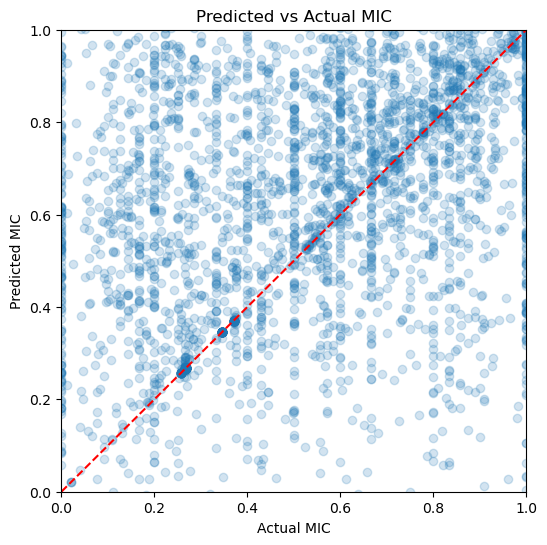

In [98]:
# let's run a random train test split first
final_ml = final_ml.drop(columns=["MUTATION"]).copy()
X_baseline = final_ml.drop(columns=["mean_log2mic"])
y_baseline = final_ml["mean_log2mic"]
print(y_baseline.isna().sum())

X_train, X_test, y_train, y_test = train_test_split(X_baseline, y_baseline, test_size=0.2, random_state=42)

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.2)
plt.plot([0, 1], [0, 1], "r--")
plt.xlabel("Actual MIC")
plt.ylabel("Predicted MIC")
plt.title("Predicted vs Actual MIC")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.show()


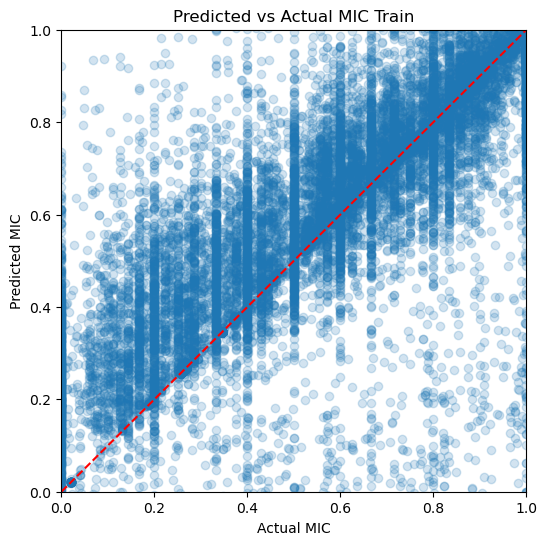

In [99]:
y_pred_train = model.predict(X_train)
plt.figure(figsize=(6, 6))
plt.scatter(y_train, y_pred_train, alpha=0.2)
plt.plot([0, 1], [0, 1], "r--")
plt.xlabel("Actual MIC")
plt.ylabel("Predicted MIC")
plt.title("Predicted vs Actual MIC Train")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.show()

TESTING ABOVE

In [116]:
merged_file = master_file.merge(
    genomic[[
        "variant_norm",
        "variant",
        "chromosome",
        "position",
        "reference_nucleotide",
        "alternative_nucleotide"
    ]],
    on="variant",
    how="left"
)


In [122]:
def audit_merge_overlap(who_df, cryptic_df):
    who_keys = who_df[["variant_norm", "drug"]].drop_duplicates()
    cryptic_keys = cryptic_df[["variant_norm", "drug"]].drop_duplicates()

    audit = who_keys.merge(
        cryptic_keys,
        on=["variant_norm", "drug"],
        how="left",
        indicator=True
    )

    print(audit["_merge"].value_counts())
    print("\nWHO rows with no CRyPTIC match:")
    print(audit[audit["_merge"] == "left_only"].head(20))

    return audit

cryptic_model = df_model.copy()
cryptic_model["drug"] = cryptic_model["DRUG_NAME"].str.lower().str.strip()
merged_file["drug"] = merged_file["drug"].str.lower().str.strip()
audit = audit_merge_overlap(merged_file, cryptic_model)

_merge
left_only     47508
both            552
right_only        0
Name: count, dtype: int64

WHO rows with no CRyPTIC match:
      variant_norm      drug     _merge
0    baca_c.102g>a  amikacin  left_only
1   baca_c.1044g>a  amikacin  left_only
2    baca_c.105c>g  amikacin  left_only
3   baca_c.1065t>g  amikacin  left_only
4   baca_c.1080g>a  amikacin  left_only
5   baca_c.1140g>a  amikacin  left_only
6   baca_c.1170g>a  amikacin  left_only
7   baca_c.1194c>t  amikacin  left_only
8   baca_c.1210c>t  amikacin  left_only
9   baca_c.1212g>a  amikacin  left_only
10  baca_c.1212g>c  amikacin  left_only
11  baca_c.1242g>a  amikacin  left_only
12   baca_c.129t>c  amikacin  left_only
13  baca_c.1317c>t  amikacin  left_only
14  baca_c.1323g>c  amikacin  left_only
15  baca_c.1348c>t  amikacin  left_only
16   baca_c.135g>a  amikacin  left_only
17  baca_c.1371g>a  amikacin  left_only
18  baca_c.1374c>t  amikacin  left_only
19   baca_c.138c>g  amikacin  left_only


In [121]:
def audit_variant_and_drug_overlap(who_df, cryptic_df):
    who_variants = set(who_df["variant_norm"].dropna())
    cryptic_variants = set(cryptic_df["variant_norm"].dropna())

    who_drugs = set(who_df["drug"].dropna())
    cryptic_drugs = set(cryptic_df["drug"].dropna())

    print("Variant overlap:")
    print("WHO variants:", len(who_variants))
    print("CRyPTIC variants:", len(cryptic_variants))
    print("Overlap:", len(who_variants & cryptic_variants))

    print("\nDrug overlap:")
    print("WHO drugs:", sorted(who_drugs))
    print("CRyPTIC drugs:", sorted(cryptic_drugs))
    print("Overlap:", sorted(who_drugs & cryptic_drugs))

audit_variant_and_drug_overlap(merged_file, cryptic_model)

Variant overlap:
WHO variants: 30647
CRyPTIC variants: 10926
Overlap: 710

Drug overlap:
WHO drugs: ['amikacin', 'bedaquiline', 'capreomycin', 'clofazimine', 'delamanid', 'ethambutol', 'ethionamide', 'isoniazid', 'kanamycin', 'levofloxacin', 'linezolid', 'moxifloxacin', 'pyrazinamide', 'rifampicin', 'streptomycin']
CRyPTIC drugs: ['amikacin', 'bedaquiline', 'clofazimine', 'delamanid', 'ethambutol', 'ethionamide', 'isoniazid', 'kanamycin', 'levofloxacin', 'linezolid', 'moxifloxacin', 'rifabutin', 'rifampicin']
Overlap: ['amikacin', 'bedaquiline', 'clofazimine', 'delamanid', 'ethambutol', 'ethionamide', 'isoniazid', 'kanamycin', 'levofloxacin', 'linezolid', 'moxifloxacin', 'rifampicin']


In [123]:
merged_file["variant_in_cryptic"] = merged_file["variant_norm"].isin(cryptic_model["variant_norm"])

print(merged_file["variant_in_cryptic"].value_counts())

variant_in_cryptic
False    200090
True       3286
Name: count, dtype: int64


In [39]:
# normalize drug names in cryptic and master file to merge on drug names as well
def normalize_drug_name(s):
    if pd.isna(s):
        return None
    return (
        str(s)
        .strip()
        .lower()
    )
cryptic["drug_norm"] = cryptic["DRUG_NAME"].apply(normalize_drug_name)
merged_file["drug_norm"] = merged_file["drug"].apply(normalize_drug_name)

merged_file_cryptic = merged_file.merge(
    cryptic[[
        "variant_norm",
        "drug_norm",
        "DRUG_NAME",
        "mean_log2mic",
        "median_log2mic",
        "count"
    ]],
    on=["variant_norm", "drug_norm"],
    how="left"
)

merged_file_cryptic.head()

,drug,gene,mutation,variant,tier,effect,genomic position,algorithm_pass_DATASET ALL,Present_SOLO_SR_DATASET ALL,Present_SOLO_R_DATASET ALL,...,variant_norm,chromosome,position,reference_nucleotide,alternative_nucleotide,drug_norm,DRUG_NAME,mean_log2mic,median_log2mic,count
0,Amikacin,bacA,c.102G>A,bacA_c.102G>A,2,synonymous_variant,"(see ""Genomic_coordinates"" sheet)",NaN,NaN,NaN,...,baca_c.102g>a,NC_000962.3,2064627.0,C,T,amikacin,NaN,NaN,NaN,NaN
1,Amikacin,bacA,c.1044G>A,bacA_c.1044G>A,2,synonymous_variant,"(see ""Genomic_coordinates"" sheet)",NaN,NaN,NaN,...,baca_c.1044g>a,NC_000962.3,2063685.0,C,T,amikacin,NaN,NaN,NaN,NaN
2,Amikacin,bacA,c.1044G>A,bacA_c.1044G>A,2,synonymous_variant,"(see ""Genomic_coordinates"" sheet)",NaN,NaN,NaN,...,baca_c.1044g>a,NC_000962.3,2063685.0,CAA,TAG,amikacin,NaN,NaN,NaN,NaN
3,Amikacin,bacA,c.105C>G,bacA_c.105C>G,2,synonymous_variant,"(see ""Genomic_coordinates"" sheet)",NaN,NaN,NaN,...,baca_c.105c>g,NC_000962.3,2064624.0,G,C,amikacin,NaN,NaN,NaN,NaN
4,Amikacin,bacA,c.1065T>G,bacA_c.1065T>G,2,synonymous_variant,"(see ""Genomic_coordinates"" sheet)",NaN,NaN,NaN,...,baca_c.1065t>g,NC_000962.3,2063658.0,TAATCGA,CAACCGC,amikacin,NaN,NaN,NaN,NaN


In [40]:
cryptic_variant_fallback = (
    cryptic
    .groupby("variant_norm", as_index=False)
    .agg(
        mean_log2mic_variant=("mean_log2mic", "mean"),
        median_log2mic_variant=("median_log2mic", "median"),
        count_variant=("count", "sum")
    )
)

merged_file_cryptic = merged_file_cryptic.merge(
    cryptic_variant_fallback,
    on="variant_norm",
    how="left"
)

merged_file_cryptic["has_exact_mic"] = merged_file_cryptic["mean_log2mic"].notna().astype(int)
merged_file_cryptic["has_variant_mic"] = merged_file_cryptic["mean_log2mic_variant"].notna().astype(int)

merged_file_cryptic["mean_log2mic_final"] = (
    merged_file_cryptic["mean_log2mic"]
    .fillna(merged_file_cryptic["mean_log2mic_variant"])
    .fillna(0)
)

merged_file_cryptic["mic_count_final"] = (
    merged_file_cryptic["count"]
    .fillna(merged_file_cryptic["count_variant"])
    .fillna(0)
)

In [41]:
print("Rows with MIC:", merged_file_cryptic["mean_log2mic"].notna().sum())
print("Total rows:", len(merged_file_cryptic))

Rows with MIC: 5676
Total rows: 203424


In [43]:
# Drop some initial columns that we won't be using, many which are text results and would be difficult to use for models
keep_columns = [
    "mutation",
    "drug",
    "gene",
    "FINAL CONFIDENCE GRADING",

    "variant",
    "chromosome",
    "position",
    "reference_nucleotide",
    "alternative_nucleotide",

    "PPV_DATASET ALL",

    # NEW MIC FEATURES
    "mean_log2mic_final",
    "mic_count_final",
    "has_exact_mic",
    "has_variant_mic"
]
merged_file_cryptic = merged_file_cryptic.copy()
merged_file_cryptic = merged_file_cryptic[keep_columns]
merged_file_cryptic.head()

,mutation,drug,gene,FINAL CONFIDENCE GRADING,variant,chromosome,position,reference_nucleotide,alternative_nucleotide,PPV_DATASET ALL,mean_log2mic_final,mic_count_final,has_exact_mic,has_variant_mic
0,c.102G>A,Amikacin,bacA,4) Not assoc w R - Interim,bacA_c.102G>A,NC_000962.3,2064627.0,C,T,0.000000,0.0,0.0,0,0
1,c.1044G>A,Amikacin,bacA,5) Not assoc w R,bacA_c.1044G>A,NC_000962.3,2063685.0,C,T,0.075644,0.0,0.0,0,0
2,c.1044G>A,Amikacin,bacA,5) Not assoc w R,bacA_c.1044G>A,NC_000962.3,2063685.0,CAA,TAG,0.075644,0.0,0.0,0,0
3,c.105C>G,Amikacin,bacA,4) Not assoc w R - Interim,bacA_c.105C>G,NC_000962.3,2064624.0,G,C,0.000000,0.0,0.0,0,0
4,c.1065T>G,Amikacin,bacA,4) Not assoc w R - Interim,bacA_c.1065T>G,NC_000962.3,2063658.0,TAATCGA,CAACCGC,0.000000,0.0,0.0,0,0


In [44]:
merged_file_cryptic["PPV_DATASET ALL"].describe()

count    203408.000000
mean          0.277983
std           0.386748
min           0.000000
25%           0.000000
50%           0.000000
75%           0.500000
max           1.000000
Name: PPV_DATASET ALL, dtype: float64

In [45]:
merged_file_cryptic["ppv"] = merged_file_cryptic["PPV_DATASET ALL"]
merged_df = merged_file_cryptic.drop(columns=["PPV_DATASET ALL"])
merged_file_cryptic = merged_file_cryptic[merged_file_cryptic["ppv"] > 0].copy()

In [46]:
# check distribution of WHO grades
print(merged_file_cryptic["FINAL CONFIDENCE GRADING"].value_counts().sort_index())
print(merged_file_cryptic["FINAL CONFIDENCE GRADING"].value_counts(normalize=True).sort_index()) # most of the grades Uncertain significance, this could be an issue

FINAL CONFIDENCE GRADING
1) Assoc w R                  10145
2) Assoc w R - Interim        15205
3) Uncertain significance     54344
4) Not assoc w R - Interim     8609
5) Not assoc w R               1633
Name: count, dtype: int64
FINAL CONFIDENCE GRADING
1) Assoc w R                  0.112802
2) Assoc w R - Interim        0.169065
3) Uncertain significance     0.604252
4) Not assoc w R - Interim    0.095724
5) Not assoc w R              0.018157
Name: proportion, dtype: float64


In [47]:
# Drop the uncertain resistance
df = merged_file_cryptic.copy()
df = df[df['FINAL CONFIDENCE GRADING'] != '3) Uncertain significance']

# check distribution of WHO grades
print(df["FINAL CONFIDENCE GRADING"].value_counts().sort_index())
print(df["FINAL CONFIDENCE GRADING"].value_counts(normalize=True).sort_index())

def make_binary_label(data):
    if "1) Assoc w R" in data or "2) Assoc w R - Interim" in data:
        return 1
    elif "4) Not assoc w R - Interim" in data or "5) Not assoc w R" in data:
        return 0
    return None

df["resistant"] = df["FINAL CONFIDENCE GRADING"].apply(make_binary_label)
df_model = df.dropna(subset=["resistant"]).copy()

print(df_model["resistant"].value_counts())

df_model = df_model.drop(columns=["FINAL CONFIDENCE GRADING"])


FINAL CONFIDENCE GRADING
1) Assoc w R                  10145
2) Assoc w R - Interim        15205
4) Not assoc w R - Interim     8609
5) Not assoc w R               1633
Name: count, dtype: int64
FINAL CONFIDENCE GRADING
1) Assoc w R                  0.285036
2) Assoc w R - Interim        0.427203
4) Not assoc w R - Interim    0.241880
5) Not assoc w R              0.045881
Name: proportion, dtype: float64
resistant
1    25350
0    10242
Name: count, dtype: int64


In [48]:
# Splitting the mutation column up to make fewer columns when one hot encoding
import re
# Amino acid 3-letter to 1-letter code map
AA_MAP = {
    'Ala': 'A', 'Arg': 'R', 'Asn': 'N', 'Asp': 'D', 'Cys': 'C',
    'Gln': 'Q', 'Glu': 'E', 'Gly': 'G', 'His': 'H', 'Ile': 'I',
    'Leu': 'L', 'Lys': 'K', 'Met': 'M', 'Phe': 'F', 'Pro': 'P',
    'Ser': 'S', 'Thr': 'T', 'Trp': 'W', 'Tyr': 'Y', 'Val': 'V',
    'Ter': '*', 'Stop': '*'
}

def parse_aa(code):
    """Convert 3-letter amino acid code to 1-letter, or return as-is if already 1-letter or stop."""
    if code == '*':
        return '*'
    return AA_MAP.get(code, code)


def extract_features(mutation):

    PREFIX = r'[cn]\.'

    # -------------------------
    # PROTEIN-LEVEL: p. notation
    # -------------------------

    # Stop extension: p.Ter559Glnext*? or p.Ter559ext*? or p.Ter628Serext*?
    p_ext = re.match(r'p\.Ter(\d+)([A-Z][a-z]{2})?ext\*\?$', mutation)
    if p_ext:
        pos, alt_aa = p_ext.groups()
        return {'mut_type': 'extension', 'position': int(pos), 'del_len': 0, 'ins_len': 0,
                'ref': '*', 'alt': parse_aa(alt_aa) if alt_aa else None}

    # Stop codon unknown delins: p.Ter839delins???
    p_ter_delins = re.match(r'p\.Ter(\d+)delins\?+$', mutation)
    if p_ter_delins:
        pos = p_ter_delins.group(1)
        return {'mut_type': 'delins', 'position': int(pos), 'del_len': 1, 'ins_len': 0,
                'ref': '*', 'alt': None}

    # Frameshift: p.Asp379fs
    p_fs = re.match(r'p\.([A-Z][a-z]{2})(\d+)fs$', mutation)
    if p_fs:
        ref_aa, pos = p_fs.groups()
        return {'mut_type': 'frameshift', 'position': int(pos), 'del_len': 0, 'ins_len': 0,
                'ref': parse_aa(ref_aa), 'alt': None}

    # Stop/nonsense: p.Trp122*
    p_stop = re.match(r'p\.([A-Z][a-z]{2})(\d+)\*$', mutation)
    if p_stop:
        ref_aa, pos = p_stop.groups()
        return {'mut_type': 'nonsense', 'position': int(pos), 'del_len': 0, 'ins_len': 0,
                'ref': parse_aa(ref_aa), 'alt': '*'}

    # Malformed nonsense: p.TrpLeu266*
    p_malformed_stop = re.match(r'p\.([A-Z][a-z]{2}[A-Z][a-z]{2})(\d+)\*$', mutation)
    if p_malformed_stop:
        ref_aa, pos = p_malformed_stop.groups()
        return {'mut_type': 'nonsense', 'position': int(pos), 'del_len': 0, 'ins_len': 0,
                'ref': None, 'alt': '*'}

    # Uncertain: p.Met1?
    p_uncertain = re.match(r'p\.([A-Z][a-z]{2})(\d+)\?$', mutation)
    if p_uncertain:
        ref_aa, pos = p_uncertain.groups()
        return {'mut_type': 'uncertain', 'position': int(pos), 'del_len': 0, 'ins_len': 0,
                'ref': parse_aa(ref_aa), 'alt': None}

    # Single AA deletion: p.Leu95del
    p_single_del = re.match(r'p\.([A-Z][a-z]{2})(\d+)del$', mutation)
    if p_single_del:
        ref_aa, pos = p_single_del.groups()
        return {'mut_type': 'del', 'position': int(pos), 'del_len': 1, 'ins_len': 0,
                'ref': parse_aa(ref_aa), 'alt': None}

    # Range AA deletion: p.Val3_Thr4del
    p_range_del = re.match(r'p\.([A-Z][a-z]{2})(\d+)_([A-Z][a-z]{2})(\d+)del$', mutation)
    if p_range_del:
        ref_aa, start, _, end = p_range_del.groups()
        return {'mut_type': 'del', 'position': int(start), 'del_len': abs(int(end) - int(start)) + 1,
                'ins_len': 0, 'ref': parse_aa(ref_aa), 'alt': None}

    # Range AA duplication: p.His68_Leu70dup
    p_range_dup = re.match(r'p\.([A-Z][a-z]{2})(\d+)_([A-Z][a-z]{2})(\d+)dup$', mutation)
    if p_range_dup:
        ref_aa, start, _, end = p_range_dup.groups()
        return {'mut_type': 'dup', 'position': int(start), 'del_len': 0,
                'ins_len': abs(int(end) - int(start)) + 1, 'ref': parse_aa(ref_aa), 'alt': None}

    # Range AA insertion: p.Val389_Asp390insGly  (one or more 3-letter AA codes)
    p_range_ins = re.match(r'p\.([A-Z][a-z]{2})(\d+)_([A-Z][a-z]{2})(\d+)ins((?:[A-Z][a-z]{2})+)$', mutation)
    if p_range_ins:
        ref_aa, start, _, end, ins_aas = p_range_ins.groups()
        ins_count = len(re.findall(r'[A-Z][a-z]{2}', ins_aas))
        return {'mut_type': 'ins', 'position': int(start), 'del_len': 0,
                'ins_len': ins_count, 'ref': parse_aa(ref_aa), 'alt': None}

    # Range AA delins: p.Pro14_Val301delinsLeu or p.Leu443_Lys446delinsProGln
    p_range_delins = re.match(r'p\.([A-Z][a-z]{2})(\d+)_([A-Z][a-z]{2})(\d+)delins((?:[A-Z][a-z]{2})+)$', mutation)
    if p_range_delins:
        ref_aa, start, _, end, ins_aas = p_range_delins.groups()
        ins_count = len(re.findall(r'[A-Z][a-z]{2}', ins_aas))
        return {'mut_type': 'delins', 'position': int(start), 'del_len': abs(int(end) - int(start)) + 1,
                'ins_len': ins_count, 'ref': parse_aa(ref_aa), 'alt': None}

    # Missense: p.Ala152Val  (must come after all range patterns)
    p_missense = re.match(r'p\.([A-Z][a-z]{2})(\d+)([A-Z][a-z]{2})$', mutation)
    if p_missense:
        ref_aa, pos, alt_aa = p_missense.groups()
        return {'mut_type': 'missense', 'position': int(pos), 'del_len': 0, 'ins_len': 0,
                'ref': parse_aa(ref_aa), 'alt': parse_aa(alt_aa)}

    # Duplication single AA: p.Ala285dup
    p_dup = re.match(r'p\.([A-Z][a-z]{2})(\d+)dup$', mutation)
    if p_dup:
        ref_aa, pos = p_dup.groups()
        return {'mut_type': 'dup', 'position': int(pos), 'del_len': 0, 'ins_len': 1,
                'ref': parse_aa(ref_aa), 'alt': None}

    # -------------------------
    # DNA/RNA-LEVEL: c. or n. notation
    # -------------------------

    snv = re.match(PREFIX + r'(-?\d+)([ACGT])>([ACGT])$', mutation)
    if snv:
        pos, ref, alt = snv.groups()
        return {'mut_type': 'SNV', 'position': int(pos), 'del_len': 0, 'ins_len': 0, 'ref': ref, 'alt': alt}

    single_del = re.match(PREFIX + r'(-?\d+)del[ACGT]*$', mutation)
    if single_del:
        pos = single_del.group(1)
        return {'mut_type': 'del', 'position': int(pos), 'del_len': 1, 'ins_len': 0, 'ref': None, 'alt': None}

    range_del = re.match(PREFIX + r'(-?\d+)_(-?\d+)del[ACGT]*$', mutation)
    if range_del:
        start, end = range_del.groups()
        return {'mut_type': 'del', 'position': int(start), 'del_len': abs(int(end) - int(start)) + 1,
                'ins_len': 0, 'ref': None, 'alt': None}

    ins = re.match(PREFIX + r'(-?\d+)_(-?\d+)ins([ACGT]+)$', mutation)
    if ins:
        start, end, bases = ins.groups()
        return {'mut_type': 'ins', 'position': int(start), 'del_len': 0, 'ins_len': len(bases), 'ref': None, 'alt': None}

    delins = re.match(PREFIX + r'(-?\d+)del[ACGT]*ins([ACGT]+)$', mutation)
    if delins:
        pos, ins_bases = delins.groups()
        return {'mut_type': 'delins', 'position': int(pos), 'del_len': 1, 'ins_len': len(ins_bases), 'ref': None, 'alt': None}

    range_delins = re.match(PREFIX + r'(-?\d+)_(-?\d+)del[ACGT]*ins[ACGT]+$', mutation)
    if range_delins:
        start, end = range_delins.groups()
        return {'mut_type': 'delins', 'position': int(start), 'del_len': abs(int(end) - int(start)) + 1,
                'ins_len': 0, 'ref': None, 'alt': None}

    dup_single = re.match(PREFIX + r'(-?\d+)dup[ACGT]*$', mutation)
    if dup_single:
        pos = dup_single.group(1)
        return {'mut_type': 'dup', 'position': int(pos), 'del_len': 0, 'ins_len': 1, 'ref': None, 'alt': None}

    dup_range = re.match(PREFIX + r'(-?\d+)_(-?\d+)dup[ACGT]*$', mutation)
    if dup_range:
        start, end = dup_range.groups()
        return {'mut_type': 'dup', 'position': int(start), 'del_len': 0,
                'ins_len': abs(int(end) - int(start)) + 1, 'ref': None, 'alt': None}

    # -------------------------
    # FREE TEXT
    # -------------------------
    mutation_lower = mutation.lower()
    if 'lof' in mutation_lower or 'loss of function' in mutation_lower:
        return {'mut_type': 'LoF', 'position': None, 'del_len': None, 'ins_len': None, 'ref': None, 'alt': None}
    if 'deletion' in mutation_lower:
        return {'mut_type': 'del', 'position': None, 'del_len': None, 'ins_len': None, 'ref': None, 'alt': None}

    return {'mut_type': 'unknown', 'position': None, 'del_len': None, 'ins_len': None, 'ref': None, 'alt': None}



df_model["gene"] = df_model["gene"].str.strip()
df_model["mutation"] = df_model["mutation"].str.strip()


# keep only necessary columns
model_df = df_model[[
    "gene",
    "ppv",
    "mutation",
    "drug",
    "resistant",
    "variant",
    "chromosome",
    "position",
    "reference_nucleotide",
    "alternative_nucleotide",
    "mean_log2mic_final",
    "mic_count_final",
    "has_exact_mic",
    "has_variant_mic"
]].copy()

one_hot_df = model_df.copy()

# --- Apply to dataframe ---
features_df = one_hot_df['mutation'].apply(extract_features).apply(pd.Series)
one_hot_df = pd.concat([one_hot_df, features_df], axis=1)

# --- One-hot encode mut_type, ref, alt ---
one_hot_df = pd.get_dummies(one_hot_df, columns=['gene', 'mut_type', 'ref', 'alt'])


print(f"num features: {len(one_hot_df.columns)}")
for c in one_hot_df.columns:
    print(c)


num features: 134
ppv
mutation
drug
resistant
variant
chromosome
position
reference_nucleotide
alternative_nucleotide
mean_log2mic_final
mic_count_final
has_exact_mic
has_variant_mic
position
del_len
ins_len
gene_PPE35
gene_Rv0010c
gene_Rv0565c
gene_Rv0678
gene_Rv1129c
gene_Rv1258c
gene_Rv1979c
gene_Rv2477c
gene_Rv2680
gene_Rv2681
gene_Rv2752c
gene_Rv2983
gene_Rv3083
gene_Rv3236c
gene_aftB
gene_ahpC
gene_atpE
gene_bacA
gene_ccsA
gene_clpC1
gene_ddn
gene_dnaA
gene_eis
gene_embA
gene_embB
gene_embC
gene_embR
gene_ethA
gene_ethR
gene_fbiA
gene_fbiB
gene_fbiC
gene_fgd1
gene_gid
gene_glpK
gene_gyrA
gene_gyrB
gene_hadA
gene_inhA
gene_katG
gene_lpqB
gene_mmpL5
gene_mmpS5
gene_mshA
gene_mtrA
gene_mtrB
gene_ndh
gene_nusG
gene_panD
gene_pepQ
gene_pncA
gene_rplC
gene_rpoA
gene_rpoB
gene_rpoC
gene_rpsA
gene_rpsL
gene_rrl
gene_rrs
gene_sigE
gene_tlyA
gene_tsnR
gene_ubiA
gene_whiB6
gene_whiB7
mut_type_LoF
mut_type_SNV
mut_type_del
mut_type_delins
mut_type_dup
mut_type_extension
mut_type_frameshift
m

In [49]:
one_hot_df.head(5)

,ppv,mutation,drug,resistant,variant,chromosome,position,reference_nucleotide,alternative_nucleotide,mean_log2mic_final,...,alt_M,alt_N,alt_P,alt_Q,alt_R,alt_S,alt_T,alt_V,alt_W,alt_Y
1,0.075644,c.1044G>A,Amikacin,0,bacA_c.1044G>A,NC_000962.3,2063685.0,C,T,0.0,...,False,False,False,False,False,False,False,False,False,False
2,0.075644,c.1044G>A,Amikacin,0,bacA_c.1044G>A,NC_000962.3,2063685.0,CAA,TAG,0.0,...,False,False,False,False,False,False,False,False,False,False
22,1.000000,c.1317C>T,Amikacin,0,bacA_c.1317C>T,NC_000962.3,2063412.0,G,A,0.0,...,False,False,False,False,False,False,True,False,False,False
27,0.333333,c.1371G>A,Amikacin,0,bacA_c.1371G>A,NC_000962.3,2063358.0,C,T,0.0,...,False,False,False,False,False,False,False,False,False,False
41,0.035714,c.1542C>T,Amikacin,0,bacA_c.1542C>T,NC_000962.3,2063187.0,G,A,0.0,...,False,False,False,False,False,False,True,False,False,False


In [50]:
one_hot_copy = one_hot_df.copy()
one_hot_copy = one_hot_df.drop(columns=["mutation", "variant", "chromosome"])
one_hot_df = one_hot_df.loc[:, ~one_hot_df.columns.duplicated()]
print(one_hot_df.shape)

(35592, 133)


In [51]:
# check distribution of WHO grades
print(one_hot_copy["resistant"].value_counts().sort_index())
print(one_hot_copy["resistant"].value_counts(normalize=True).sort_index()) # most of the grades Uncertain significance, this could be an issue

resistant
0    10242
1    25350
Name: count, dtype: int64
resistant
0    0.287761
1    0.712239
Name: proportion, dtype: float64


In [ ]:
drug_list = ['Amikacin', 'Bedaquiline', 'Capreomycin', 'Clofazimine', 'Delamanid',
             'Ethambutol', 'Ethionamide', 'Isoniazid', 'Kanamycin', 'Levofloxacin', 
             'Linezolid', 'Moxifloxacin', 'Pyrazinamide', 'Rifampicin', 'Streptomycin']

# get the smiles for the drugs
def get_smiles(drug_name):
    try:
        compounds = pcp.get_compounds(drug_name, "name")
        if len(compounds) > 0:
            return compounds[0].connectivity_smiles
    except:
        return None
    return None

#apply to the list of TB drugs
TB_drugs = pd.DataFrame({"drug": drug_list})
TB_drugs['smiles'] = TB_drugs["drug"].apply(get_smiles)

# add fingerprints to dataset
morgan_generator = GetMorganGenerator(radius=2, fpSize=256)

def smiles_to_fingerprint(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    fingerprint = morgan_generator.GetFingerprint(mol)
    array = np.zeros((256, ), dtype=int)
    ConvertToNumpyArray(fingerprint, array)
    
    return array

TB_drugs["fingerprint"] = TB_drugs["smiles"].apply(smiles_to_fingerprint)

# merge drugs to the model df
final_data = one_hot_copy.merge(TB_drugs, on="drug", how="left")
final_data.head()

,ppv,drug,resistant,position,reference_nucleotide,alternative_nucleotide,mean_log2mic_final,mic_count_final,has_exact_mic,has_variant_mic,...,alt_P,alt_Q,alt_R,alt_S,alt_T,alt_V,alt_W,alt_Y,smiles,fingerprint
0,0.075644,Amikacin,0,2063685.0,C,T,0.0,0.0,0,0,...,False,False,False,False,False,False,False,False,C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, ..."
1,0.075644,Amikacin,0,2063685.0,CAA,TAG,0.0,0.0,0,0,...,False,False,False,False,False,False,False,False,C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, ..."
2,1.000000,Amikacin,0,2063412.0,G,A,0.0,0.0,0,0,...,False,False,False,False,True,False,False,False,C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, ..."
3,0.333333,Amikacin,0,2063358.0,C,T,0.0,0.0,0,0,...,False,False,False,False,False,False,False,False,C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, ..."
4,0.035714,Amikacin,0,2063187.0,G,A,0.0,0.0,0,0,...,False,False,False,False,True,False,False,False,C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, ..."


In [53]:
ml_data = final_data.copy()

#keep track of mapping for later
lookup_drugs = dict(enumerate(ml_data["drug"].astype("category").cat.categories))
print(lookup_drugs) # this is the mapping of drug names to codes, we will need this to identify the codes for the drugs we want to hold out

ml_data["drug"] = ml_data["drug"].astype("category").cat.codes
ml_data.head()

{0: 'Amikacin', 1: 'Bedaquiline', 2: 'Capreomycin', 3: 'Clofazimine', 4: 'Delamanid', 5: 'Ethambutol', 6: 'Ethionamide', 7: 'Isoniazid', 8: 'Kanamycin', 9: 'Levofloxacin', 10: 'Linezolid', 11: 'Moxifloxacin', 12: 'Pyrazinamide', 13: 'Rifampicin', 14: 'Streptomycin'}


,ppv,drug,resistant,position,reference_nucleotide,alternative_nucleotide,mean_log2mic_final,mic_count_final,has_exact_mic,has_variant_mic,...,alt_P,alt_Q,alt_R,alt_S,alt_T,alt_V,alt_W,alt_Y,smiles,fingerprint
0,0.075644,0,0,2063685.0,C,T,0.0,0.0,0,0,...,False,False,False,False,False,False,False,False,C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, ..."
1,0.075644,0,0,2063685.0,CAA,TAG,0.0,0.0,0,0,...,False,False,False,False,False,False,False,False,C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, ..."
2,1.000000,0,0,2063412.0,G,A,0.0,0.0,0,0,...,False,False,False,False,True,False,False,False,C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, ..."
3,0.333333,0,0,2063358.0,C,T,0.0,0.0,0,0,...,False,False,False,False,False,False,False,False,C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, ..."
4,0.035714,0,0,2063187.0,G,A,0.0,0.0,0,0,...,False,False,False,False,True,False,False,False,C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, ..."


In [54]:
# Now we need to convert the fingerprint arrays into separate columns for each bit, so we can use them in the model
encoded_df = pd.DataFrame(ml_data["fingerprint"].tolist(), index=ml_data.index)
encoded_df.columns = [f"fp_{i}" for i in range(encoded_df.shape[1])] # change the fingerprints from an array to columns

final_ml = pd.concat([ml_data.drop(columns=["fingerprint", "smiles"]), encoded_df], axis=1)
final_ml = final_ml.loc[:, ~final_ml.columns.duplicated()].copy()
final_ml = final_ml.drop(
    columns=[
        "mean_log2mic",
        "median_log2mic",
        "count",
        "mean_log2mic_variant",
        "median_log2mic_variant",
        "count_variant"
    ],
    errors="ignore"
)
print(final_ml.shape)
final_ml.head()

(35592, 386)


,ppv,drug,resistant,position,reference_nucleotide,alternative_nucleotide,mean_log2mic_final,mic_count_final,has_exact_mic,has_variant_mic,...,fp_246,fp_247,fp_248,fp_249,fp_250,fp_251,fp_252,fp_253,fp_254,fp_255
0,0.075644,0,0,2063685.0,C,T,0.0,0.0,0,0,...,0,0,0,0,0,1,0,0,0,1
1,0.075644,0,0,2063685.0,CAA,TAG,0.0,0.0,0,0,...,0,0,0,0,0,1,0,0,0,1
2,1.000000,0,0,2063412.0,G,A,0.0,0.0,0,0,...,0,0,0,0,0,1,0,0,0,1
3,0.333333,0,0,2063358.0,C,T,0.0,0.0,0,0,...,0,0,0,0,0,1,0,0,0,1
4,0.035714,0,0,2063187.0,G,A,0.0,0.0,0,0,...,0,0,0,0,0,1,0,0,0,1


In [55]:
gene_cols = [c for c in final_ml.columns if c.startswith("gene_")]
rare = [c for c in gene_cols if final_ml[c].sum() < 10]

final_ml = final_ml.drop(columns=rare)
final_ml["ref_len"] = final_ml["reference_nucleotide"].astype(str).str.len()
final_ml["alt_len"] = final_ml["alternative_nucleotide"].astype(str).str.len()

final_ml["ref_base"] = final_ml["reference_nucleotide"].where(
    final_ml["ref_len"] == 1, "LONG"
)
final_ml["alt_base"] = final_ml["alternative_nucleotide"].where(
    final_ml["alt_len"] == 1, "LONG"
)
final_ml = final_ml.drop(
    columns=["reference_nucleotide", "alternative_nucleotide"],
    errors="ignore"
)

final_ml = pd.get_dummies(final_ml, columns=["ref_base", "alt_base"])
final_ml.head()

,ppv,drug,resistant,position,mean_log2mic_final,mic_count_final,has_exact_mic,has_variant_mic,del_len,ins_len,...,ref_base_A,ref_base_C,ref_base_G,ref_base_LONG,ref_base_T,alt_base_A,alt_base_C,alt_base_G,alt_base_LONG,alt_base_T
0,0.075644,0,0,2063685.0,0.0,0.0,0,0,0.0,0.0,...,False,True,False,False,False,False,False,False,False,True
1,0.075644,0,0,2063685.0,0.0,0.0,0,0,0.0,0.0,...,False,False,False,True,False,False,False,False,True,False
2,1.000000,0,0,2063412.0,0.0,0.0,0,0,0.0,0.0,...,False,False,True,False,False,True,False,False,False,False
3,0.333333,0,0,2063358.0,0.0,0.0,0,0,0.0,0.0,...,False,True,False,False,False,False,False,False,False,True
4,0.035714,0,0,2063187.0,0.0,0.0,0,0,0.0,0.0,...,False,False,True,False,False,True,False,False,False,False


In [56]:
# check distribution of WHO grades
print(final_ml["resistant"].value_counts().sort_index())
print(final_ml["resistant"].value_counts(normalize=True).sort_index()) # most of the grades Uncertain significance, this could be an issue

resistant
0    10242
1    25350
Name: count, dtype: int64
resistant
0    0.287761
1    0.712239
Name: proportion, dtype: float64


In [57]:
final_ml = final_ml.dropna(subset=["resistant"]).copy()
# check distribution of WHO grades
print(final_ml["resistant"].value_counts().sort_index())
print(final_ml["resistant"].value_counts(normalize=True).sort_index()) # most of the grades Uncertain significance, this could be an issue
final_ml.head()

resistant
0    10242
1    25350
Name: count, dtype: int64
resistant
0    0.287761
1    0.712239
Name: proportion, dtype: float64


,ppv,drug,resistant,position,mean_log2mic_final,mic_count_final,has_exact_mic,has_variant_mic,del_len,ins_len,...,ref_base_A,ref_base_C,ref_base_G,ref_base_LONG,ref_base_T,alt_base_A,alt_base_C,alt_base_G,alt_base_LONG,alt_base_T
0,0.075644,0,0,2063685.0,0.0,0.0,0,0,0.0,0.0,...,False,True,False,False,False,False,False,False,False,True
1,0.075644,0,0,2063685.0,0.0,0.0,0,0,0.0,0.0,...,False,False,False,True,False,False,False,False,True,False
2,1.000000,0,0,2063412.0,0.0,0.0,0,0,0.0,0.0,...,False,False,True,False,False,True,False,False,False,False
3,0.333333,0,0,2063358.0,0.0,0.0,0,0,0.0,0.0,...,False,True,False,False,False,False,False,False,False,True
4,0.035714,0,0,2063187.0,0.0,0.0,0,0,0.0,0.0,...,False,False,True,False,False,True,False,False,False,False


##### NOW WE CAN START TESTING MODELS #####

0
MAE: 0.04470743588949063
R2: 0.8016932753558388


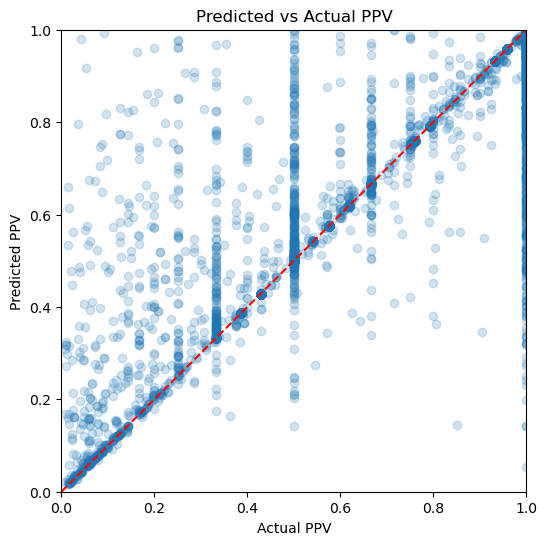

In [58]:
# let's run a random train test split first
X_baseline = final_ml.drop(columns=["resistant", "ppv", "drug"])
y_baseline = final_ml["ppv"]
print(y_baseline.isna().sum())

X_train, X_test, y_train, y_test = train_test_split(X_baseline, y_baseline, test_size=0.2, random_state=42)

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.2)
plt.plot([0, 1], [0, 1], "r--")
plt.xlabel("Actual PPV")
plt.ylabel("Predicted PPV")
plt.title("Predicted vs Actual PPV")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.show()


In [59]:
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

MAE: 0.04470743588949063
R2: 0.8016932753558388


### Let's change and do a mutation holdout to see if we can create a successful model that will predict PPV based on a new mutation

In [60]:
gene_key = final_ml.filter(like="gene_").idxmax(axis=1)
final_ml["mutation_key"] = gene_key + "_" + final_ml['position'].astype(str)

# features and the target
X = final_ml.drop(columns=["resistant", "ppv", "mutation_key"])
y = final_ml["ppv"]
group = final_ml["mutation_key"]

# Now we can use groupKFold to split the data
from sklearn.model_selection import GroupKFold
gkf = GroupKFold(n_splits=5)
for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups=group)):
    print(f"Fold {fold + 1}")
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    # Train a simple model (e.g., Random Forest)
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)
    
    # Predict and evaluate
    y_pred = model.predict(X_test)
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("R2:", r2_score(y_test, y_pred))

Fold 1
MAE: 0.0638039875202261
R2: 0.6723261018094643
Fold 2
MAE: 0.06751335821088875
R2: 0.6747978179765648
Fold 3
MAE: 0.06293368997215794
R2: 0.6731285768088607
Fold 4
MAE: 0.06015728814021141
R2: 0.7045220371728349
Fold 5
MAE: 0.0612020950200211
R2: 0.7004658552789873


## Add more positional data by downloading gene info

In [61]:
myco = pd.read_csv("Mycobacterium_tuberculosis_H37Rv_txt_v5.txt", sep="\t")
myco.columns = myco.columns.str.strip() # strip column names of whitespace
print(myco.columns)
print(myco.head())
myco['gene_length'] = myco['Stop'] - myco['Start'] + 1
myco_subset = myco[['Refseq_ID', 'Start', 'Stop', 'Name','gene_length']].copy()
myco_subset.head()

Index(['Refseq_ID', 'Mycobrowser_Version', 'Feature', 'Start', 'Stop', 'Score',
       'Strand', 'Frame', 'Locus', 'Name', 'Function', 'Product', 'Comments',
       'UniProt_AC', 'Is_Pseudogene', 'Functional_Category',
       'Protein Data Bank', 'PFAM', 'UniProt', 'Gene Ontology',
       'Enzyme Classification', 'Drug Resistance Mutations', 'InterPro',
       'UniProtKB/TrEMBL', 'SWISS-MODEL', 'Orthologues M. leprae',
       'Orthologues M. marinum', 'Orthologues M. smegmatis',
       'Orthologues M. bovis', 'Orthologues M. lepromatosis',
       'Orthologues M. tuberculosis', 'Orthologues M. abscessus',
       'Orthologues M. haemophilum', 'Orthologues M. orygis',
       'Orthologues M. tuberculosis.1'],
      dtype='object')
     Refseq_ID Mycobrowser_Version Feature   Start    Stop Score Strand  \
0  NC_000962.3      Mycobrowser_v5   ncRNA  759479  759610     .      +   
1  NC_000962.3      Mycobrowser_v5   ncRNA  786021  786074     .      +   
2  NC_000962.3      Mycobrowser_v5   n

,Refseq_ID,Start,Stop,Name,gene_length
0,NC_000962.3,759479,759610,ncRv10666,132
1,NC_000962.3,786021,786074,ncRv10685,54
2,NC_000962.3,80240,80440,ncRv10071,201
3,NC_000962.3,80254,80344,ncRv10071c,91
4,NC_000962.3,156452,156567,ncRv10128,116


In [62]:
new_data = final_ml.copy()
needed_genes = new_data.filter(like="gene_").columns.str.replace("gene_", "", regex=False)
print(needed_genes)

matched_myco = myco_subset[myco_subset['Name'].isin(needed_genes)].copy()
print(matched_myco)

Index(['PPE35', 'Rv0010c', 'Rv0565c', 'Rv0678', 'Rv1129c', 'Rv1258c',
       'Rv1979c', 'Rv2477c', 'Rv2681', 'Rv2752c', 'Rv2983', 'Rv3083',
       'Rv3236c', 'aftB', 'ahpC', 'bacA', 'ccsA', 'clpC1', 'ddn', 'dnaA',
       'eis', 'embA', 'embB', 'embC', 'embR', 'ethA', 'ethR', 'fbiA', 'fbiB',
       'fbiC', 'fgd1', 'gid', 'glpK', 'gyrA', 'gyrB', 'hadA', 'inhA', 'katG',
       'lpqB', 'mmpL5', 'mshA', 'mtrA', 'mtrB', 'ndh', 'nusG', 'panD', 'pepQ',
       'pncA', 'rplC', 'rpoA', 'rpoB', 'rpoC', 'rpsA', 'rpsL', 'rrl', 'rrs',
       'sigE', 'tlyA', 'tsnR', 'ubiA', 'whiB6', 'whiB7'],
      dtype='object')
        Refseq_ID    Start     Stop     Name  gene_length
132   NC_000962.3  1471846  1473382      rrs         1537
165   NC_000962.3        1     1524     dnaA         1524
169   NC_000962.3     7302     9818     gyrA         2517
174   NC_000962.3    13133    13558  Rv0010c          426
310   NC_000962.3   490783   491793     fgd1         1011
...           ...      ...      ...      ...  

In [63]:
gene_cols = [c for c in new_data.columns if c.startswith("gene_") and not c.startswith("gene_length")]
new_data['gene_name'] = new_data[gene_cols].idxmax(axis=1).str.replace("gene_", "", regex=False).str.lower()
matched_myco['gene_name'] = matched_myco['Name'].str.strip().str.lower()

new_data = new_data.merge(matched_myco[['gene_name', 'gene_length', 'Start', 'Stop']], on='gene_name', how='left')
new_data = new_data.drop(columns=['gene_name'])
new_data.head()

,ppv,drug,resistant,position,mean_log2mic_final,mic_count_final,has_exact_mic,has_variant_mic,del_len,ins_len,...,ref_base_T,alt_base_A,alt_base_C,alt_base_G,alt_base_LONG,alt_base_T,mutation_key,gene_length,Start,Stop
0,0.075644,0,0,2063685.0,0.0,0.0,0,0,0.0,0.0,...,False,False,False,False,False,True,gene_bacA_2063685.0,1920,2062809,2064728
1,0.075644,0,0,2063685.0,0.0,0.0,0,0,0.0,0.0,...,False,False,False,False,True,False,gene_bacA_2063685.0,1920,2062809,2064728
2,1.000000,0,0,2063412.0,0.0,0.0,0,0,0.0,0.0,...,False,True,False,False,False,False,gene_bacA_2063412.0,1920,2062809,2064728
3,0.333333,0,0,2063358.0,0.0,0.0,0,0,0.0,0.0,...,False,False,False,False,False,True,gene_bacA_2063358.0,1920,2062809,2064728
4,0.035714,0,0,2063187.0,0.0,0.0,0,0,0.0,0.0,...,False,True,False,False,False,False,gene_bacA_2063187.0,1920,2062809,2064728


In [64]:
## add relative position of mutation in the gene
new_data['relative_position'] = (new_data['position'] - new_data['Start']) + 1
new_data['norm_position'] = new_data['relative_position'] / new_data['gene_length']
new_data = new_data.drop(columns=['Start', 'Stop'])
new_data.head()

,ppv,drug,resistant,position,mean_log2mic_final,mic_count_final,has_exact_mic,has_variant_mic,del_len,ins_len,...,ref_base_T,alt_base_A,alt_base_C,alt_base_G,alt_base_LONG,alt_base_T,mutation_key,gene_length,relative_position,norm_position
0,0.075644,0,0,2063685.0,0.0,0.0,0,0,0.0,0.0,...,False,False,False,False,False,True,gene_bacA_2063685.0,1920,877.0,0.456771
1,0.075644,0,0,2063685.0,0.0,0.0,0,0,0.0,0.0,...,False,False,False,False,True,False,gene_bacA_2063685.0,1920,877.0,0.456771
2,1.000000,0,0,2063412.0,0.0,0.0,0,0,0.0,0.0,...,False,True,False,False,False,False,gene_bacA_2063412.0,1920,604.0,0.314583
3,0.333333,0,0,2063358.0,0.0,0.0,0,0,0.0,0.0,...,False,False,False,False,False,True,gene_bacA_2063358.0,1920,550.0,0.286458
4,0.035714,0,0,2063187.0,0.0,0.0,0,0,0.0,0.0,...,False,True,False,False,False,False,gene_bacA_2063187.0,1920,379.0,0.197396


In [65]:
## change to distances
new_data['distance_to_end'] = new_data['gene_length'] - new_data['relative_position']
new_data['codon_position'] = new_data['relative_position'] % 3
new_data = new_data.drop(columns=['relative_position', 'gene_length'])
new_data.head()

,ppv,drug,resistant,position,mean_log2mic_final,mic_count_final,has_exact_mic,has_variant_mic,del_len,ins_len,...,ref_base_T,alt_base_A,alt_base_C,alt_base_G,alt_base_LONG,alt_base_T,mutation_key,norm_position,distance_to_end,codon_position
0,0.075644,0,0,2063685.0,0.0,0.0,0,0,0.0,0.0,...,False,False,False,False,False,True,gene_bacA_2063685.0,0.456771,1043.0,1.0
1,0.075644,0,0,2063685.0,0.0,0.0,0,0,0.0,0.0,...,False,False,False,False,True,False,gene_bacA_2063685.0,0.456771,1043.0,1.0
2,1.000000,0,0,2063412.0,0.0,0.0,0,0,0.0,0.0,...,False,True,False,False,False,False,gene_bacA_2063412.0,0.314583,1316.0,1.0
3,0.333333,0,0,2063358.0,0.0,0.0,0,0,0.0,0.0,...,False,False,False,False,False,True,gene_bacA_2063358.0,0.286458,1370.0,1.0
4,0.035714,0,0,2063187.0,0.0,0.0,0,0,0.0,0.0,...,False,True,False,False,False,False,gene_bacA_2063187.0,0.197396,1541.0,1.0


In [66]:
## drop the original position column since we have the relative position now
new_data_clean = new_data.copy()
new_data_clean = new_data_clean.drop(columns=['position'])
new_data_clean.head()

,ppv,drug,resistant,mean_log2mic_final,mic_count_final,has_exact_mic,has_variant_mic,del_len,ins_len,gene_PPE35,...,ref_base_T,alt_base_A,alt_base_C,alt_base_G,alt_base_LONG,alt_base_T,mutation_key,norm_position,distance_to_end,codon_position
0,0.075644,0,0,0.0,0.0,0,0,0.0,0.0,False,...,False,False,False,False,False,True,gene_bacA_2063685.0,0.456771,1043.0,1.0
1,0.075644,0,0,0.0,0.0,0,0,0.0,0.0,False,...,False,False,False,False,True,False,gene_bacA_2063685.0,0.456771,1043.0,1.0
2,1.000000,0,0,0.0,0.0,0,0,0.0,0.0,False,...,False,True,False,False,False,False,gene_bacA_2063412.0,0.314583,1316.0,1.0
3,0.333333,0,0,0.0,0.0,0,0,0.0,0.0,False,...,False,False,False,False,False,True,gene_bacA_2063358.0,0.286458,1370.0,1.0
4,0.035714,0,0,0.0,0.0,0,0,0.0,0.0,False,...,False,True,False,False,False,False,gene_bacA_2063187.0,0.197396,1541.0,1.0


In [67]:
X_old = final_ml.drop(columns=["ppv", "resistant", "mutation_key"], errors="ignore")
y = final_ml["ppv"]
groups = final_ml["mutation_key"]

X_new = new_data_clean.drop(columns=["ppv", "resistant", "mutation_key"], errors="ignore")
y_new = new_data_clean["ppv"]
groups_new = new_data_clean["mutation_key"]

gkf = GroupKFold(n_splits=5)
for fold, (train_idx, test_idx) in enumerate(gkf.split(X_old, y, groups=groups)):
    print(f"Fold {fold + 1} - Old Data")
    X_train, X_test = X_old.iloc[train_idx], X_old.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    print("Old MAE:", mean_absolute_error(y_test, y_pred))
    print("Old R2:", r2_score(y_test, y_pred))


for fold, (train_idx, test_idx) in enumerate(gkf.split(X_new, y_new, groups=groups_new)):
    print(f"Fold {fold + 1} - New Data")
    X_train, X_test = X_new.iloc[train_idx], X_new.iloc[test_idx]
    y_train, y_test = y_new.iloc[train_idx], y_new.iloc[test_idx]

    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    print("New MAE:", mean_absolute_error(y_test, y_pred))
    print("New R2:", r2_score(y_test, y_pred))



Fold 1 - Old Data
Old MAE: 0.0638039875202261
Old R2: 0.6723261018094643
Fold 2 - Old Data
Old MAE: 0.06751335821088875
Old R2: 0.6747978179765648
Fold 3 - Old Data
Old MAE: 0.06293368997215794
Old R2: 0.6731285768088607
Fold 4 - Old Data
Old MAE: 0.06015728814021141
Old R2: 0.7045220371728349
Fold 5 - Old Data
Old MAE: 0.0612020950200211
Old R2: 0.7004658552789873
Fold 1 - New Data
New MAE: 0.06438081537737242
New R2: 0.6958044745191531
Fold 2 - New Data
New MAE: 0.06724822612733791
New R2: 0.7034228512375045
Fold 3 - New Data
New MAE: 0.06220679594646841
New R2: 0.7018104619042556
Fold 4 - New Data
New MAE: 0.05882095010918471
New R2: 0.7299895090678733
Fold 5 - New Data
New MAE: 0.06144506339701234
New R2: 0.7173835219443527


In [68]:
# let's add bins
def ppv_bin(ppv):
    if ppv >= 0.8:
        return "3"
    elif ppv >= 0.6:
        return "2"
    elif ppv >= 0.2:
        return "1"
    else:
        return "0"

new_data_clean["ppv_bin"] = new_data_clean["ppv"].apply(ppv_bin)
new_data_clean.head()

,ppv,drug,resistant,mean_log2mic_final,mic_count_final,has_exact_mic,has_variant_mic,del_len,ins_len,gene_PPE35,...,alt_base_A,alt_base_C,alt_base_G,alt_base_LONG,alt_base_T,mutation_key,norm_position,distance_to_end,codon_position,ppv_bin
0,0.075644,0,0,0.0,0.0,0,0,0.0,0.0,False,...,False,False,False,False,True,gene_bacA_2063685.0,0.456771,1043.0,1.0,0
1,0.075644,0,0,0.0,0.0,0,0,0.0,0.0,False,...,False,False,False,True,False,gene_bacA_2063685.0,0.456771,1043.0,1.0,0
2,1.000000,0,0,0.0,0.0,0,0,0.0,0.0,False,...,True,False,False,False,False,gene_bacA_2063412.0,0.314583,1316.0,1.0,3
3,0.333333,0,0,0.0,0.0,0,0,0.0,0.0,False,...,False,False,False,False,True,gene_bacA_2063358.0,0.286458,1370.0,1.0,1
4,0.035714,0,0,0.0,0.0,0,0,0.0,0.0,False,...,True,False,False,False,False,gene_bacA_2063187.0,0.197396,1541.0,1.0,0


In [ ]:
from sklearn.ensemble import RandomForestClassifier

X = new_data_clean.drop(columns=["ppv", "ppv_bin", "resistant", "mutation_key", "drug"], errors="ignore")
y = new_data_clean["ppv_bin"]
groups = new_data_clean["mutation_key"]

gkf = GroupKFold(n_splits=5)
all_results = []
metrics = []

for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups)):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    sample_weights = X_train["has_exact_mic"] * 3 + 1 + X_train["has_variant_mic"] * 2 # add some weights to samples with MIC data
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    model = RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train, sample_weight=sample_weights)
    y_pred = model.predict(X_test)

    metrics.append({
        "fold": fold + 1,
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred)
    })

    fold_df = pd.DataFrame({
        "fold": fold + 1,
        "mutation": groups.iloc[test_idx].values,
        "actual": y_test.to_numpy(),
        "predicted": y_pred
    })

    all_results.append(fold_df)

    print(f"\nFold {fold+1}")
    print(classification_report(y_test, y_pred))
    print(f"Balanced Accuracy: {balanced_accuracy_score(y_test, y_pred)}")

results_df = pd.concat(all_results, ignore_index=True)
metrics_df = pd.DataFrame(metrics)




Fold 1
              precision    recall  f1-score   support

           0       0.71      0.62      0.66       413
           1       0.86      0.87      0.87      2586
           2       0.95      0.92      0.94      1494
           3       0.85      0.87      0.86      2626

    accuracy                           0.87      7119
   macro avg       0.84      0.82      0.83      7119
weighted avg       0.87      0.87      0.87      7119

Balanced Accuracy: 0.8203852360639817

Fold 2
              precision    recall  f1-score   support

           0       0.70      0.59      0.64       451
           1       0.85      0.82      0.84      2445
           2       0.94      0.88      0.91      1539
           3       0.81      0.88      0.84      2684

    accuracy                           0.84      7119
   macro avg       0.82      0.79      0.81      7119
weighted avg       0.84      0.84      0.84      7119

Balanced Accuracy: 0.7924398605656723

Fold 3
              precision    rec

In [89]:
from sklearn.model_selection import GroupKFold

gkf = GroupKFold(n_splits=5)

for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups=groups)):
    
    print(f"\n=== Fold {fold+1} ===")
    
    # unseen mutations in this fold
    test_mutations = groups.iloc[test_idx].unique()
    
    print(f"Number of unseen mutations: {len(test_mutations)}")
    print("Sample mutations:")
    print(test_mutations[:10])  # print first 10


=== Fold 1 ===
Number of unseen mutations: 2426
Sample mutations:
['gene_bacA_2062881.0' 'gene_bacA_2063911.0' 'gene_ccsA_620280.0'
 'gene_ccsA_620316.0' 'gene_ccsA_620553.0' 'gene_ccsA_619962.0'
 'gene_eis_2715345.0' 'gene_eis_2714846.0' 'gene_rrs_1472892.0'
 'gene_rrs_1473053.0']

=== Fold 2 ===
Number of unseen mutations: 2427
Sample mutations:
['gene_bacA_2063412.0' 'gene_bacA_2063358.0' 'gene_bacA_2064177.0'
 'gene_ccsA_620029.0' 'gene_ccsA_620358.0' 'gene_eis_2715342.0'
 'gene_eis_2714172.0' 'gene_eis_2715126.0' 'gene_eis_2715291.0'
 'gene_rrs_1473061.0']

=== Fold 3 ===
Number of unseen mutations: 2426
Sample mutations:
['gene_bacA_2063106.0' 'gene_bacA_2062922.0' 'gene_ccsA_620397.0'
 'gene_ccsA_620619.0' 'gene_ccsA_620625.0' 'gene_ccsA_619965.0'
 'gene_ccsA_619969.0' 'gene_eis_2715344.0' 'gene_rrs_1472895.0'
 'gene_rrs_1473034.0']

=== Fold 4 ===
Number of unseen mutations: 2427
Sample mutations:
['gene_bacA_2063685.0' 'gene_bacA_2063187.0' 'gene_bacA_2062947.0'
 'gene_bacA_2

In [90]:
results_df.head()

,fold,mutation,actual,predicted
0,1,gene_bacA_2062881.0,3,1
1,1,gene_bacA_2063911.0,0,0
2,1,gene_ccsA_620280.0,0,0
3,1,gene_ccsA_620316.0,3,0
4,1,gene_ccsA_620316.0,3,0


In [91]:
results_df["correct"] = results_df["actual"] == results_df["predicted"]
print(results_df["correct"].mean())

0.8583108563722185


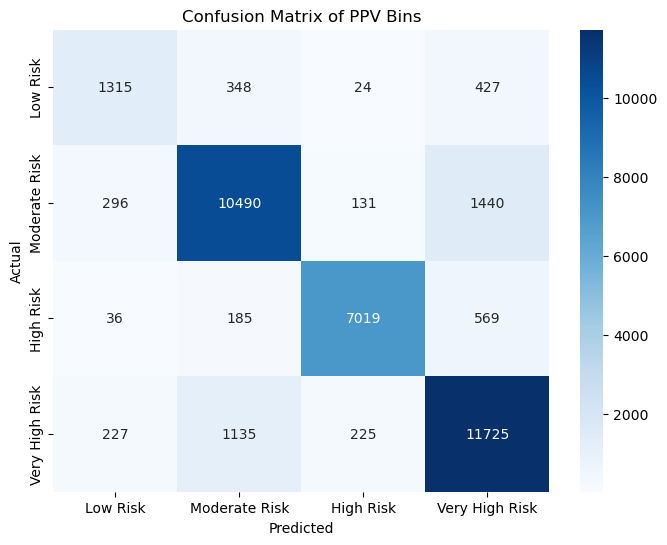

In [92]:
# let's look plot the distribution of predicted vs actual for each class as a confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
cm = confusion_matrix(results_df["actual"], results_df["predicted"], labels=["0", "1", "2", "3"])
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Low Risk", "Moderate Risk", "High Risk", "Very High Risk"],
            yticklabels=["Low Risk", "Moderate Risk", "High Risk", "Very High Risk"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix of PPV Bins")
plt.show()
